In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, SelectKBest, f_classif
from sklearn.decomposition import PCA

features_df = pd.read_csv("gait_features_clean.csv")
print(features_df.shape)
features_df.head()

X = features_df.drop(columns=["subject", "label"])
y = features_df["label"]
groups = features_df["subject"]

sample_features = ["eeg_alpha_ch0", "eeg_beta_ch0", "eeg_gamma_ch0", "emg_rms_ch0", "emg_mav_ch0", "emg_wl_ch0"]

(18774, 95)


## Feature Engineering

1. Feature transformation, actually apply scaling (was only set up before, never run)

In [2]:
from sklearn.model_selection import GroupShuffleSplit

# Group-aware split so no subject appears in both train and test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)

Train shape: (14969, 93)  Test shape: (3805, 93)


2. Feature selection: Variance Threshold

In [3]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.0)  # removes features with zero variance (constant columns)
vt.fit(X_train_scaled)

low_variance_cols = X_train_scaled.columns[~vt.get_support()].tolist()
print("Zero/near-zero variance features found:", low_variance_cols)

X_train_vt = X_train_scaled.drop(columns=low_variance_cols)
X_test_vt = X_test_scaled.drop(columns=low_variance_cols)
print("Shape after variance filtering:", X_train_vt.shape)

Zero/near-zero variance features found: []
Shape after variance filtering: (14969, 93)


3. Feature selection: Mutual Information

In [4]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train_vt, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_vt.columns).sort_values(ascending=False)

print("Top 15 features by Mutual Information:")
print(mi_series.head(15))

Top 15 features by Mutual Information:
eeg_gamma_ch8    0.230504
eeg_beta_ch8     0.228696
emg_wl_ch0       0.145949
eeg_alpha_ch8    0.145780
emg_mav_ch1      0.132640
eeg_alpha_ch4    0.117356
emg_rms_ch1      0.116174
emg_rms_ch5      0.115396
eeg_beta_ch4     0.115165
emg_mav_ch4      0.113633
emg_mav_ch0      0.113308
emg_rms_ch0      0.111636
emg_rms_ch4      0.111450
emg_mav_ch5      0.110033
emg_wl_ch1       0.108341
dtype: float64


4. Feature selection: SelectKBest

In [5]:
from sklearn.feature_selection import SelectKBest, f_classif

k = 30  # keep top 30 features, adjust based on the MI ranking above
selector = SelectKBest(score_func=f_classif, k=k)
X_train_kbest = selector.fit_transform(X_train_vt, y_train)
X_test_kbest = selector.transform(X_test_vt)

selected_features = X_train_vt.columns[selector.get_support()].tolist()
print(f"Selected top {k} features:")
print(selected_features)

Selected top 30 features:
['eeg_alpha_ch2', 'eeg_alpha_ch3', 'eeg_alpha_ch6', 'eeg_alpha_ch8', 'eeg_alpha_ch9', 'eeg_alpha_ch10', 'eeg_beta_ch2', 'eeg_beta_ch3', 'eeg_beta_ch6', 'eeg_beta_ch8', 'eeg_beta_ch9', 'eeg_beta_ch10', 'eeg_gamma_ch2', 'eeg_gamma_ch3', 'eeg_gamma_ch8', 'emg_rms_ch0', 'emg_rms_ch1', 'emg_rms_ch7', 'emg_rms_ch10', 'emg_rms_ch11', 'emg_mav_ch0', 'emg_mav_ch1', 'emg_mav_ch7', 'emg_mav_ch10', 'emg_mav_ch11', 'emg_wl_ch0', 'emg_wl_ch1', 'emg_wl_ch7', 'emg_wl_ch10', 'emg_wl_ch11']


5. Removing redundant features, act on the correlation heatmap

In [6]:
corr_matrix = X_train_vt.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_features = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]
print(f"Highly correlated (>0.95) redundant features to drop: {len(redundant_features)}")
print(redundant_features[:10], "..." if len(redundant_features) > 10 else "")

X_train_final = X_train_vt.drop(columns=redundant_features)
X_test_final = X_test_vt.drop(columns=redundant_features)
print("Shape after removing redundant features:", X_train_final.shape)

Highly correlated (>0.95) redundant features to drop: 24
['eeg_alpha_ch10', 'eeg_beta_ch10', 'eeg_beta_ch17', 'eeg_gamma_ch17', 'emg_mav_ch0', 'emg_mav_ch1', 'emg_mav_ch2', 'emg_mav_ch3', 'emg_mav_ch4', 'emg_mav_ch5'] ...
Shape after removing redundant features: (14969, 69)


## Visualizations

6. Distribution of numerical features, Histogram/KDE (on a representative subset, not all 93)

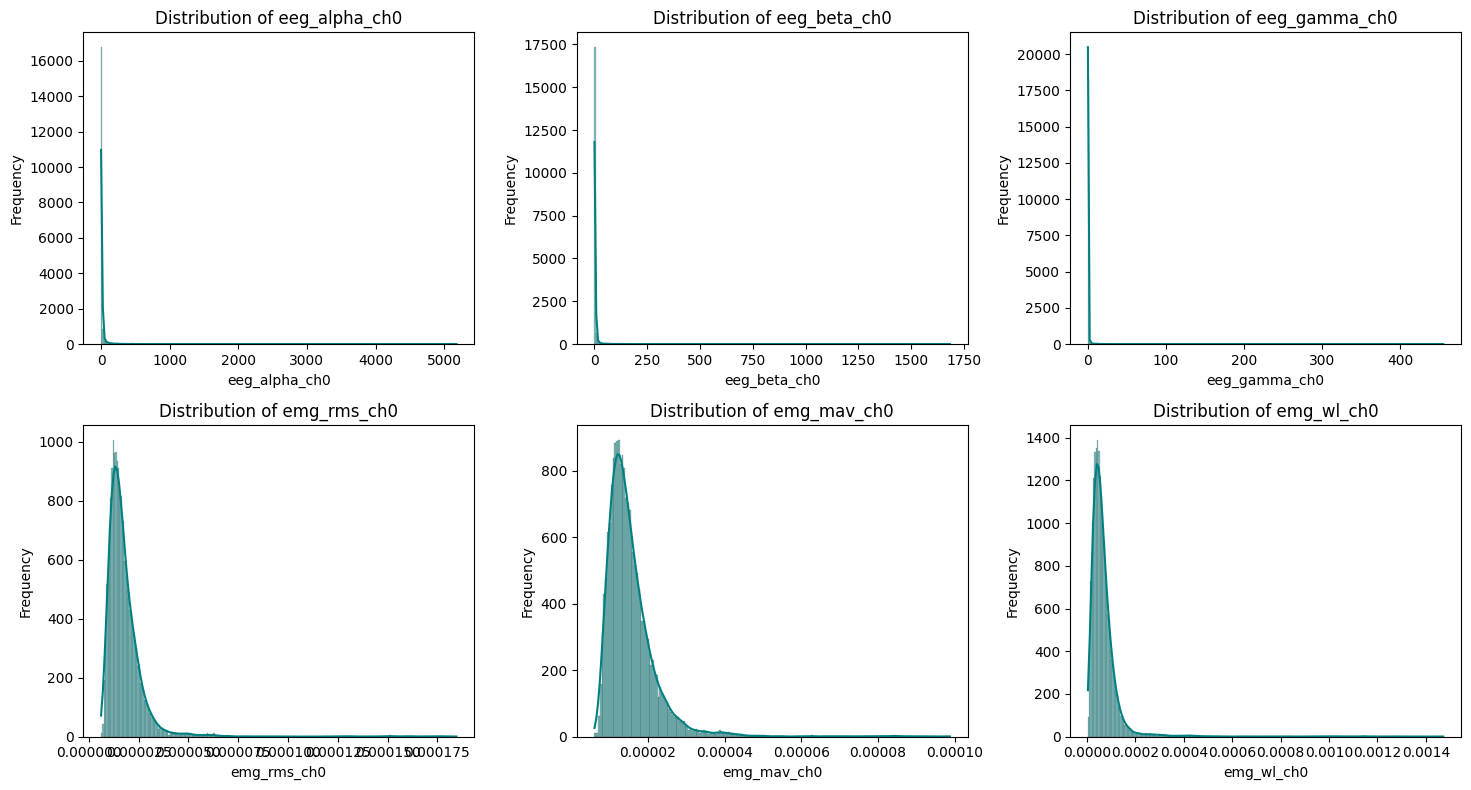

In [10]:
sample_features = ["eeg_alpha_ch0", "eeg_beta_ch0", "eeg_gamma_ch0", "emg_rms_ch0", "emg_mav_ch0", "emg_wl_ch0"]
# adjust these names to match your actual column names if the channel index differs

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, sample_features):
    sns.histplot(features_df[feat], kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribution of {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

*Interpretation:* All six features are heavily right-skewed, with most values clustered near zero and a long tail of rare, large values. This is expected for power/amplitude-based signal features (EEG band power, EMG RMS/MAV/waveform length), which are mathematically bounded at zero and spike during brief high-activity moments. This skew motivates a log transformation before scaling, since StandardScaler alone does not correct distribution shape.

7. Log Transformation: Correcting Right-Skew Observed Above

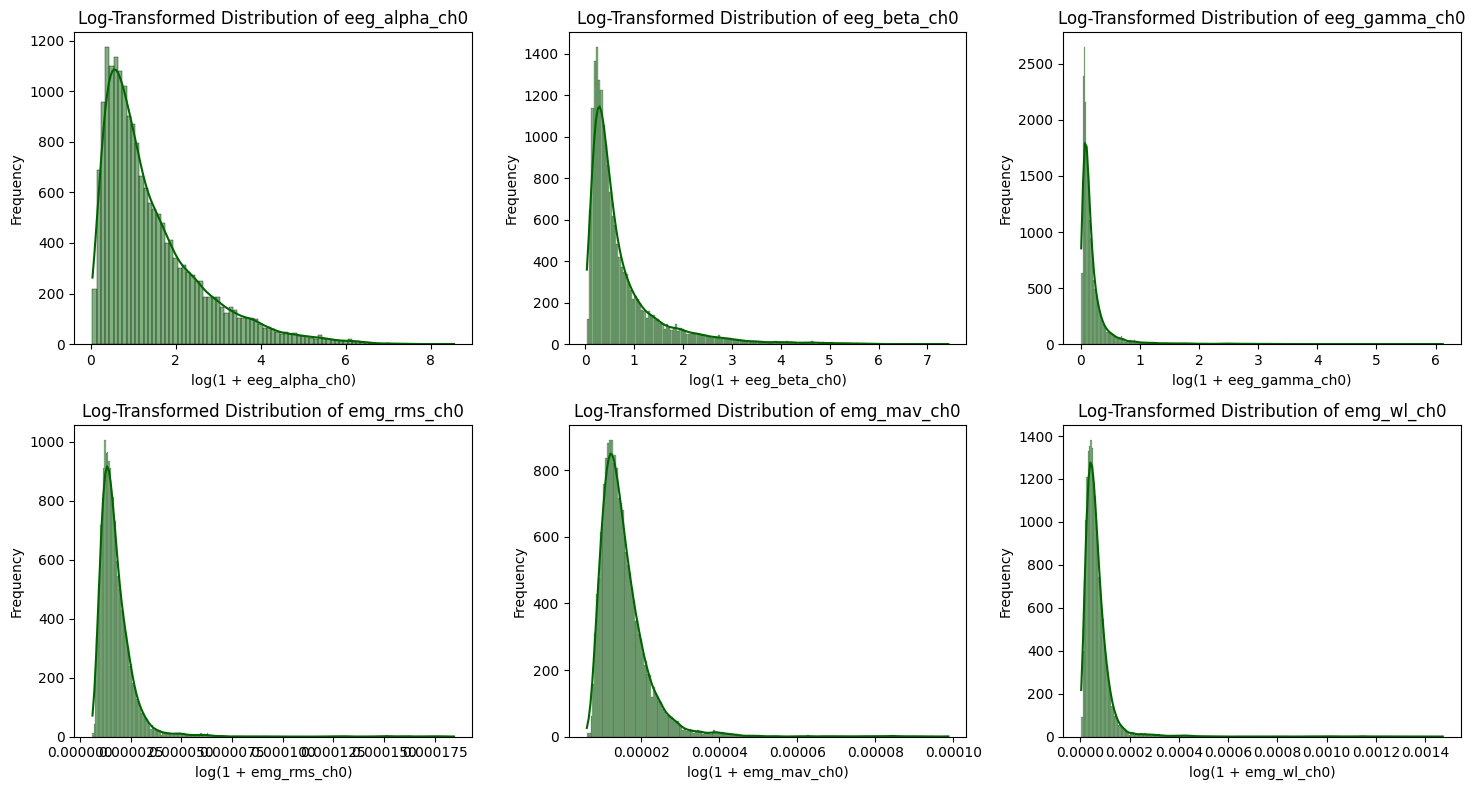

In [11]:
for feat in sample_features:
    features_df[f"{feat}_log"] = np.log1p(features_df[feat])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, sample_features):
    sns.histplot(features_df[f"{feat}_log"], kde=True, ax=ax, color="darkgreen")
    ax.set_title(f"Log-Transformed Distribution of {feat}")
    ax.set_xlabel(f"log(1 + {feat})")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

*Interpretation:* After applying log1p, all six features show a noticeably more symmetric, closer-to-normal distribution, with the extreme right tail compressed. This confirms the transformation is appropriate for this data and makes these features better suited to distance-based models (SVM, k-NN) and to standardization in the next step, since scaling now acts on a more balanced distribution rather than one dominated by rare outliers.

8. Box plots for outlier analysis (on the same sample features)

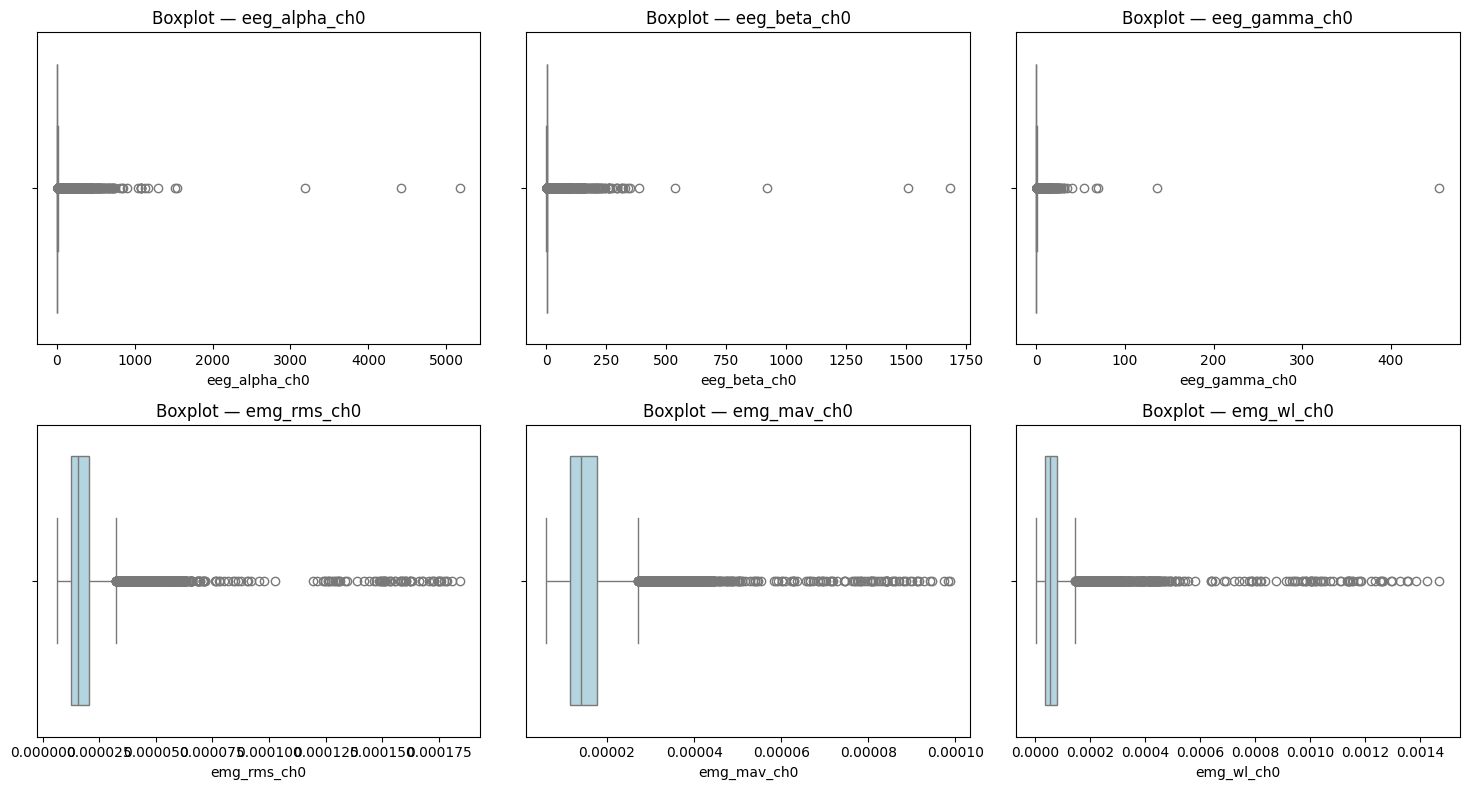

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, sample_features):
    sns.boxplot(x=features_df[feat], ax=ax, color="lightblue")
    ax.set_title(f"Boxplot — {feat}")
    ax.set_xlabel(feat)
plt.tight_layout()
plt.show()

*Interpretation:* Every feature shows a heavily compressed box near zero with a long spray of points flagged as outliers extending far to the right, consistent with the right-skew already seen in the histograms. EMG features (bottom row) show a visible box with a moderate whisker, while EEG features (top row) are so skewed that the box itself is barely visible against the outlier spread. This confirms these "outliers" are not data errors but genuine high-amplitude epochs (likely faster walking or brief muscle bursts),reinforcing that the earlier artifact-filtering step, not simple IQR trimming, was the correct approach for this data.

9. Pair plot (selected features only and not run on all 93, it'll be unreadable and extremely slow)

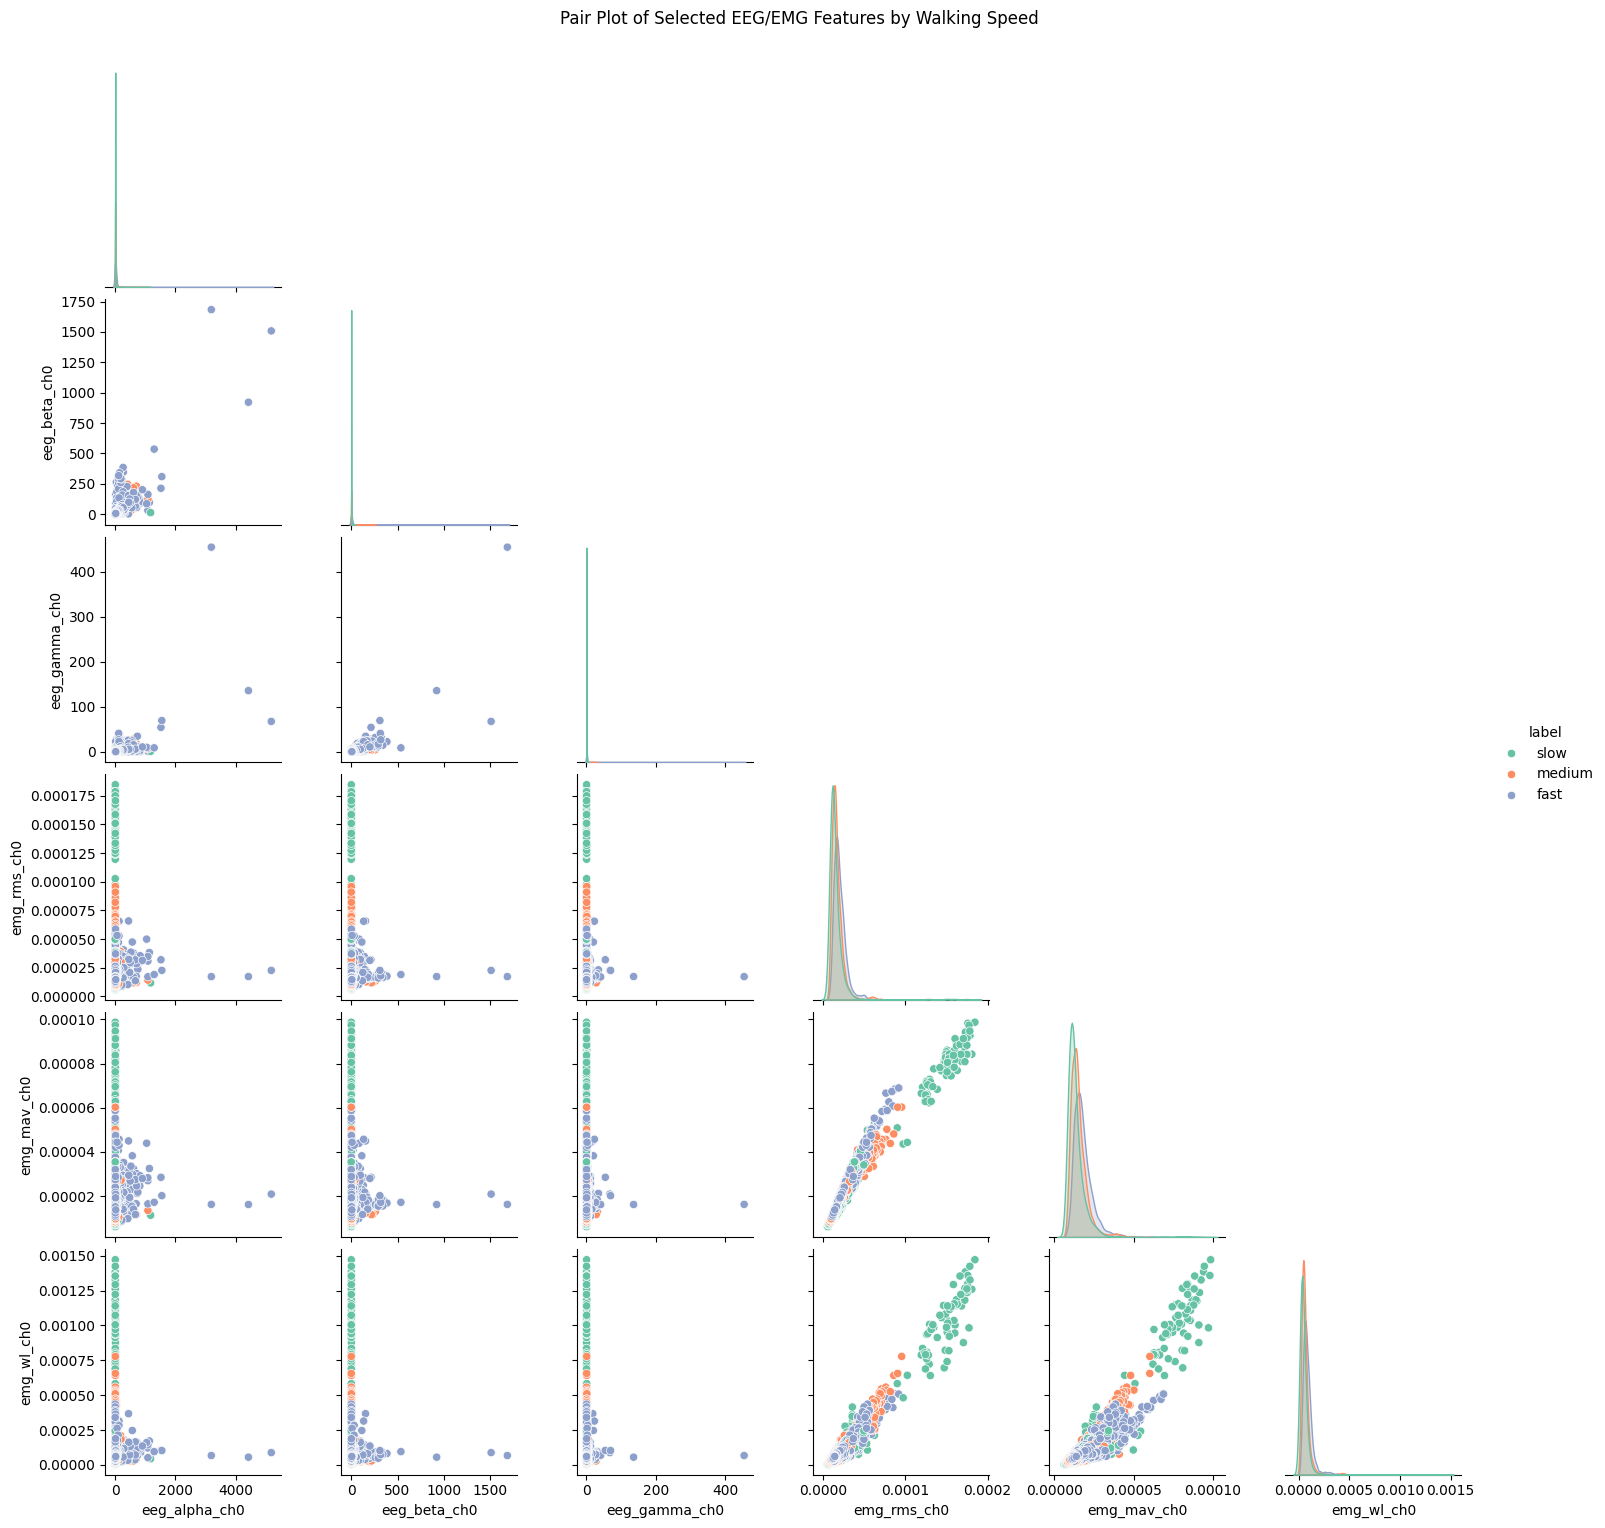

In [13]:
pairplot_features = sample_features + ["label"]
sns.pairplot(features_df[pairplot_features], hue="label", palette="Set2", corner=True)
plt.suptitle("Pair Plot of Selected EEG/EMG Features by Walking Speed", y=1.02)
plt.show()

*Interpretation:* The EMG-vs-EMG panels (rms, mav, wl, visible in the bottom-right block of the grid) show a strong, clean, positive linear relationship with each other across all three classes expected, since RMS, MAV, and waveform length are all different mathematical summaries of the same underlying muscle activation signal. Within that EMG block, "fast" (blue) and "slow" (green) points partially separate along the diagonal, with slow-speed points reaching notably higher MAV/waveform-length values in a subset of cases, an unexpected but real pattern worth flagging rather than assuming faster always means higher muscle amplitude in this dataset.

EEG features (top-left block: alpha, beta, gamma) show far more scatter and much weaker class separation, most points from all three classes cluster tightly near zero, with only a handful of high-power outliers (mostly "fast") standing apart from the rest. The EEG-vs-EMG cross panels (top-right and bottom-left blocks) show essentially no clear linear relationship between the two modalities, as expected, since brain activity and muscle activity are physiologically distinct signals, not measurements of the same underlying quantity.

Overall, this reinforces that the EMG-derived features appear to carry more visually separable class information than EEG-derived features in this raw (pre-log) view, something worth re-checking once the log-transformed features are used consistently across the full 93-feature set.    

10. Scatter plots, relationship between two variables

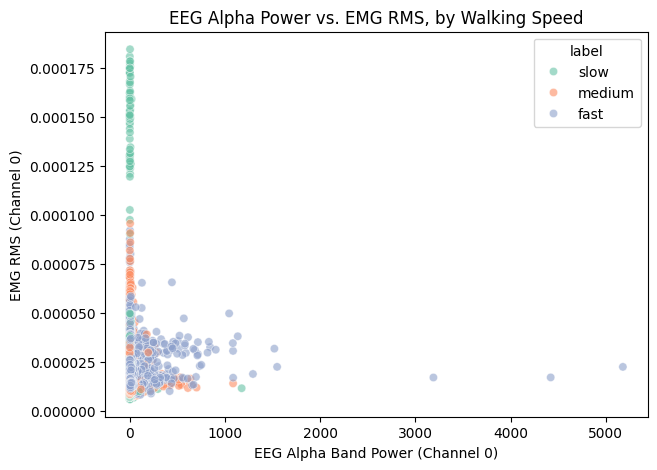

In [14]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=features_df, x="eeg_alpha_ch0", y="emg_rms_ch0", hue="label", palette="Set2", alpha=0.6)
plt.title("EEG Alpha Power vs. EMG RMS, by Walking Speed")
plt.xlabel("EEG Alpha Band Power (Channel 0)")
plt.ylabel("EMG RMS (Channel 0)")
plt.show()

Interpretation: The three walking-speed classes overlap substantially in this two-feature view, with no clean linear or clustered boundary between slow, medium, and fast. Interestingly, EMG RMS alone shows a mild separation along the vertical axis (slow-speed points reach higher RMS values in a few cases), while EEG alpha power stays compressed near zero for almost all classes with only a few large outliers. This indicates that no single pair of raw features cleanly separates the three classes, supporting the case for a full 93-feature model (and PCA/multivariate analysis) rather than expecting any one feature pair to do the job alone.

11. Violin plot, better than boxplot for showing shape, not just spread

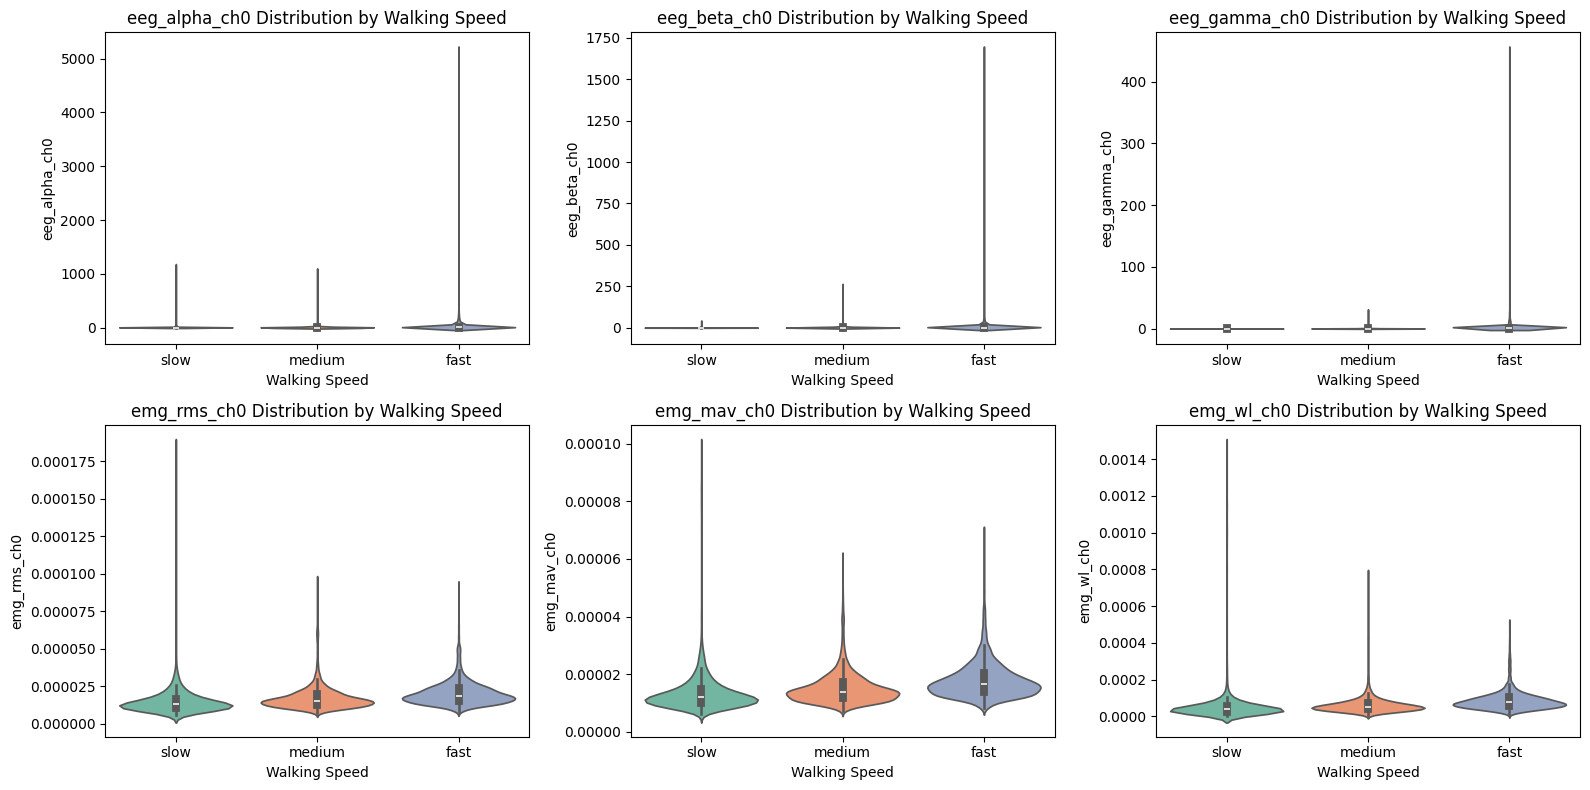

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, sample_features):
    sns.violinplot(
        data=features_df,
        x="label",
        y=feat,
        hue="label",
        order=["slow", "medium", "fast"],
        ax=ax,
        palette="Set2",
        legend=False
    )
    ax.set_title(f"{feat} Distribution by Walking Speed")
    ax.set_xlabel("Walking Speed")
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()

Interpretation: The violin shapes confirm what the box plots suggested, with more detail: all three classes across all six features show a similar "teardrop" shape, dense near zero, thinning into a long tail, rather than genuinely distinct distribution shapes per class. The EMG violins (bottom row) show a slightly wider, more elevated body for "fast" compared to "slow," consistent with higher average muscle activation at faster speeds, while EEG violins (top row) look nearly identical in shape across all three classes, reinforcing that EEG alone shows weaker class separation than EMG in this dataset.

12. Line plot

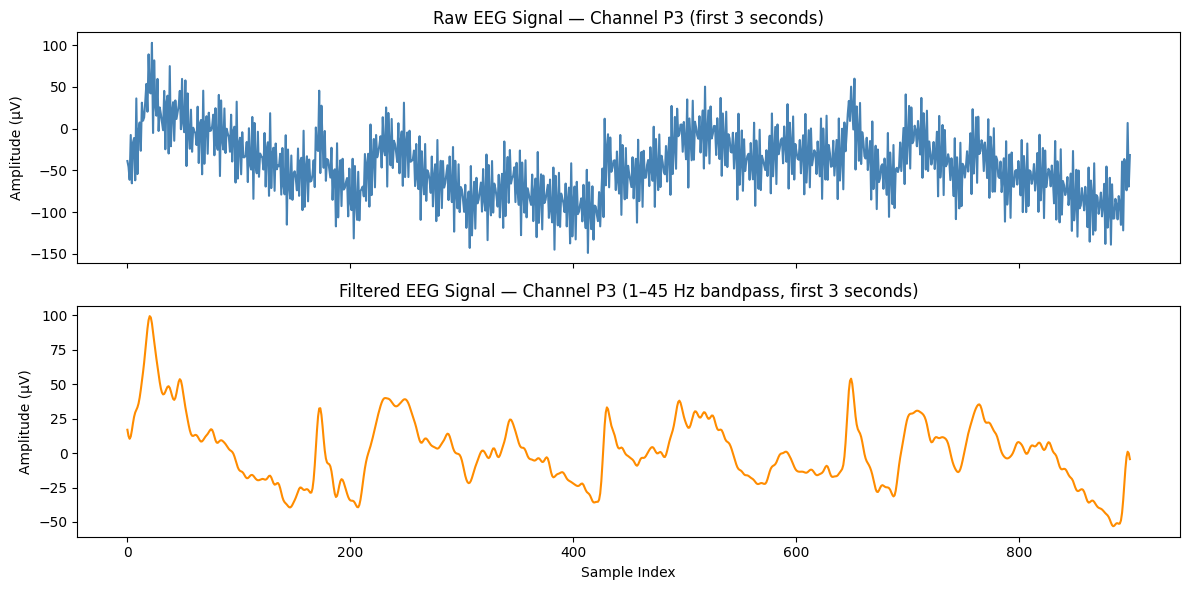

In [23]:
import os
from scipy import signal

EEG_DIR = "Dataset/EEG_Data/EEG.csv"  # adjust to your actual path
EEG_CHANNELS = [
    "P3", "C3", "F3", "Fz", "F4", "C4", "P4", "Cz", "CM",
    "Fp1", "Fp2", "T3", "T5", "O1", "O2", "F7", "F8", "T6", "T4"
]

def eeg_path(sub, spd):
    return os.path.join(EEG_DIR, f"S{sub}_{spd}_raw.csv")

def bandpass_filter(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    b, a = signal.butter(order, [low / nyq, high / nyq], btype="band")
    return signal.filtfilt(b, a, data, axis=0)

FS_EEG = 300
eeg_clean = pd.read_csv(eeg_path("1", "0.5"), skiprows=15)
eeg_clean[EEG_CHANNELS] = eeg_clean[EEG_CHANNELS].apply(pd.to_numeric, errors="coerce").interpolate(limit_direction="both")

eeg_filtered = eeg_clean.copy()
eeg_filtered[EEG_CHANNELS] = bandpass_filter(eeg_clean[EEG_CHANNELS].values, 1, 45, FS_EEG)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(eeg_clean["P3"].values[:900], color="steelblue")
axes[0].set_title("Raw EEG Signal — Channel P3 (first 3 seconds)")
axes[0].set_ylabel("Amplitude (µV)")
axes[1].plot(eeg_filtered["P3"].values[:900], color="darkorange")
axes[1].set_title("Filtered EEG Signal — Channel P3 (1–45 Hz bandpass, first 3 seconds)")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("Amplitude (µV)")
plt.tight_layout()
plt.show()

Interpretation: line plot is the only way to actually show what "raw vs. filtered" signal looks like, no other plot type in this list can demonstrate that the bandpass filtering step did something real. This is arguably the single most important visualization for a signal-based project specifically, since it directly justifies your preprocessing choice.

13. PCA 2D projection

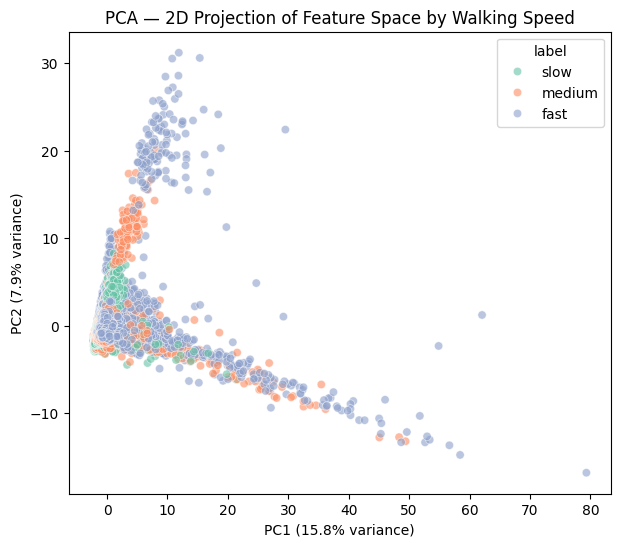

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(7, 6))
scatter = sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, palette="Set2", alpha=0.6)
plt.title("PCA — 2D Projection of Feature Space by Walking Speed")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.show()

Interpretation: The first two principal components together explain only about 23.7% of total variance (15.8% + 7.9%), meaning this 2D view is a fairly coarse simplification of the full 93-feature space, a caveat worth stating directly rather than over-interpreting the plot. Even so, there is a visible trend: "fast" (blue) points dominate the upper and outer regions of the plot, while "slow" (green) and "medium" (orange) cluster more tightly near the origin with substantial overlap between each other. This suggests fast walking produces more extreme/distinctive feature values overall, while distinguishing slow from medium may be the harder classification task for your models, worth watching for specifically in your confusion matrices once you start training.